> # Exact simulation with Qiskit SDK primitives

## **StatevectorEstimator & StatevectorSampler**
<h4>

> reference primitives in the Qiskit SDK 

- use to run your workflow locally

- These simulations do not support modeling device noise

Refernces:

https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives

</h4>

> # Reference implementation of EstimatorV2 in qiskit.primitives 
<h4>

Runs on a local statevector simulators is the **StatevectorEstimator class**

> INPUTS: circuits, observables, and parameters as inputs 

> RETURNS: the locally computed expectation values

Expected input type for the observables :  qiskit.quantum_info.SparsePauliOp. 


**NOTE:**

1. you can  run Estimator on non-parametrized circuits

2. **Any circuit passed to an Estimator must not include any measurements.**

</h4>

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


In [2]:
import numpy as np
from qiskit.circuit import QuantumCircuit

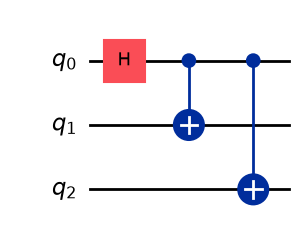

In [3]:
# GHZ circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.draw("mpl")

In [4]:
from qiskit.quantum_info import SparsePauliOp

observables_labels = ["ZZZ","IZZ","ZIZ","ZZI"]

observables = [SparsePauliOp(label) for label in observables_labels]

In [5]:
# Generate a pass manager without providing a backend
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit = pm.run(qc)

> Initialize Estimator

In [6]:
from qiskit.primitives import StatevectorEstimator

estimator = StatevectorEstimator()

> Run and get results

This example only uses one circuit (of type QuantumCircuit) and 4 observable.

In [7]:
job = estimator.run([(qc, observables)])
result = job.result()
print(f" > Expectation value: {result[0].data.evs}")
print(f" > Metadata: {result[0].metadata}")

 > Expectation value: [0. 1. 1. 1.]
 > Metadata: {'target_precision': 0.0, 'circuit_metadata': {}}


> # Reference implementations of SamplerV2 in qiskit.primitives 
<h4>

** StatevectorSampler class**

> INPUTS:  circuits and parameters  

> RETURNS:  results from sampling from the output probability distributions as a quasi-probability distribution of output states

**Note:** 
1. you can run a single parametrized circuit, but you can also run Sampler on non-parametrized circuits.

2. Any quantum circuit passed to a Sampler must include measurements.

> Measurement outcome samples are returned as bitstrings or counts

</h4>

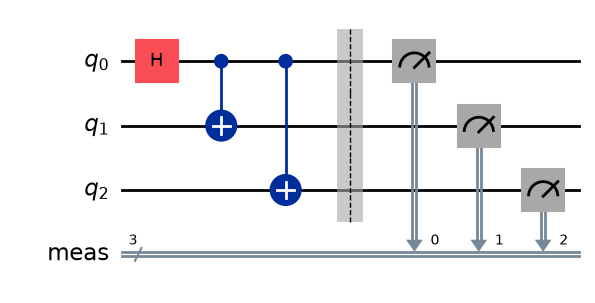

In [8]:
# GHZ circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)

qc.measure_all()
qc.draw("mpl")

In [9]:
# Generate a pass manager without providing a backend
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit = pm.run(qc)

> Initialize Sampler

In [10]:

from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

In [11]:
# execute 1 circuit with Sampler
job = sampler.run([qc])
pub_result = job.result()[0]

# Access result data for PUB 0
data_pub = pub_result.data
# Access bitstring for the classical register "meas"
bitstrings = data_pub.meas.get_bitstrings()
print(f"The number of bitstrings is: {len(bitstrings)}")
# Get counts for the classical register "meas"
counts = data_pub.meas.get_counts()
print(f"The counts are: {counts}")

The number of bitstrings is: 1024
The counts are: {'111': 513, '000': 511}
